# Gradient Boosting: A Comprehensive Guide

Gradient Boosting is a powerful ensemble method that builds models sequentially, where each new model corrects the errors of the previous ones. It includes popular algorithms like XGBoost, LightGBM, and scikit-learn's GradientBoostingClassifier.

In this notebook, we'll cover:
1. Basic concepts of Gradient Boosting
2. Data preparation and visualization
3. Model concepts and implementation
4. Using scikit-learn's Gradient Boosting
5. Model evaluation and hyperparameter tuning

# Simple Explanation: What Does the Code Below Do?

Imagine you're training a new employee by having them learn from mistakes. First, they make their best attempt. Then a second employee learns to correct whatever the first one got wrong. Then a third corrects the combined errors of the first two — and so on.

Gradient Boosting does exactly this:
1. **Tree 1**: Makes initial predictions.
2. **Tree 2**: Learns to predict the *residual errors* of Tree 1.
3. **Tree 3**: Learns to predict the *residual errors* of Trees 1+2.
4. ... and so on for N trees.

The 'gradient' refers to using gradient descent to minimize the prediction error.

Here's what the code does:
1. Loads a dataset for classification.
2. Explains the boosting concept with step-by-step visualization.
3. Uses scikit-learn's GradientBoostingClassifier.
4. Tunes learning rate and n_estimators, visualizes feature importances.

In short: Gradient Boosting builds weak learners sequentially, each fixing the mistakes of the previous ones!

In [1]:
# Create a virtual environment and install required libraries
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed in the virtual environment.')
else:
    print('Could not find pip in the virtual environment. Please check your Python installation.')

Virtual environment already exists at ml_env
Required libraries installed in the virtual environment.


# 1. Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Generating Sample Data

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']


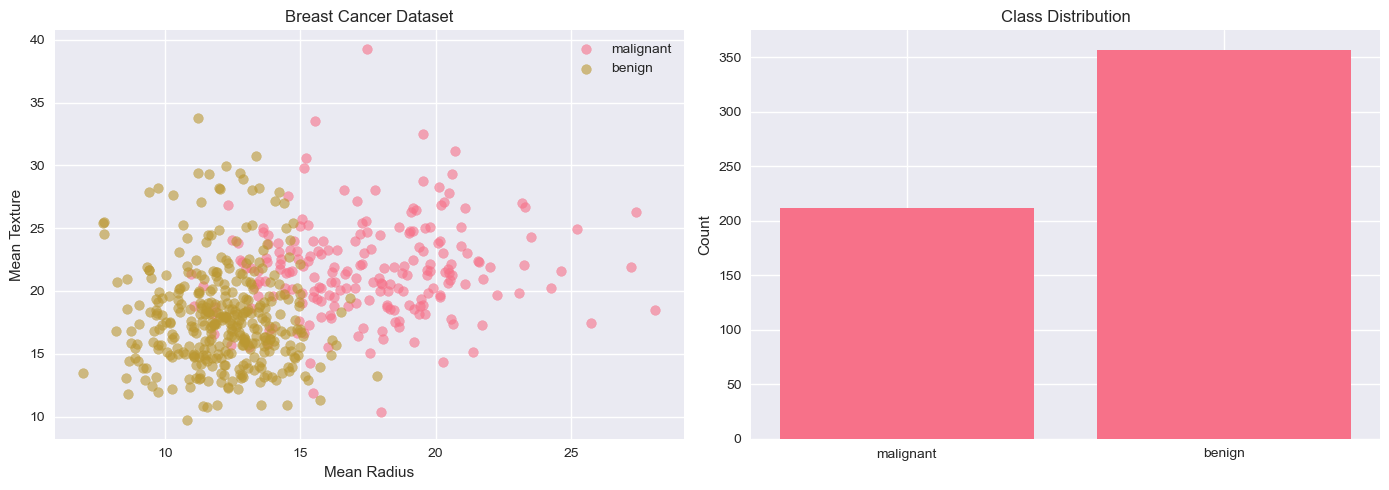

In [3]:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
feature_names = cancer.feature_names
class_names = cancer.target_names

print('Dataset shape:', X.shape)
print('Classes:', class_names)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Quick data visualization
df = pd.DataFrame(X[:, :4], columns=feature_names[:4])
df['target'] = y

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, cls in enumerate(class_names):
    subset = df[df['target'] == i]
    axes[0].scatter(subset['mean radius'], subset['mean texture'], label=cls, alpha=0.6)
axes[0].set_xlabel('Mean Radius')
axes[0].set_ylabel('Mean Texture')
axes[0].set_title('Breast Cancer Dataset')
axes[0].legend()

# Class distribution
axes[1].bar(class_names, np.bincount(y))
axes[1].set_title('Class Distribution')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

# 3. Understanding Gradient Boosting — Stage-wise Learning

Key concepts:
1. **Weak Learners**: Individual shallow decision trees (stumps).
2. **Residuals/Pseudo-residuals**: The 'errors' each new tree tries to correct.
3. **Learning Rate (shrinkage)**: Scales each tree's contribution to prevent overfitting.
4. **Loss Function**: Binary cross-entropy for classification, MSE for regression.

Formula: F(x) = F₀(x) + η·h₁(x) + η·h₂(x) + ... + η·hₙ(x)

where η is the learning rate and hᵢ are the weak learners.

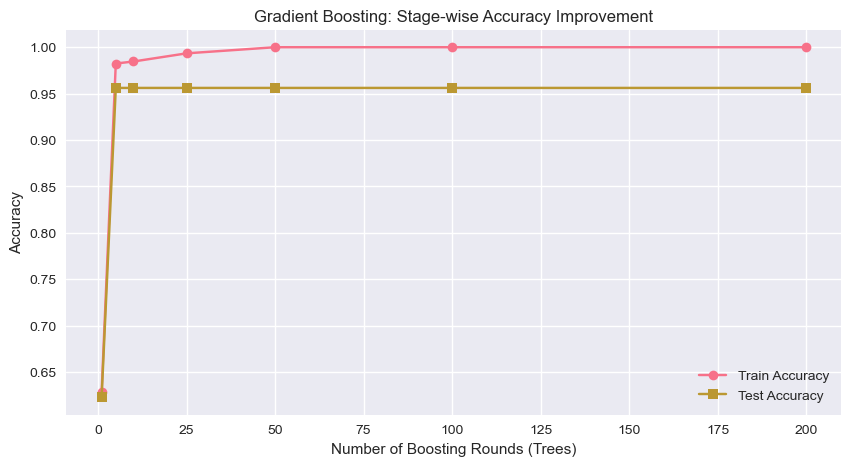

Notice how both train and test accuracy improve as we add more trees!


In [4]:
# Demonstrate how accuracy improves as we add more trees
n_estimators_range = [1, 5, 10, 25, 50, 100, 200]
train_accs, test_accs = [], []

for n in n_estimators_range:
    gb = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, max_depth=3, random_state=42)
    gb.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, gb.predict(X_train)))
    test_accs.append(accuracy_score(y_test, gb.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(n_estimators_range, train_accs, marker='o', label='Train Accuracy')
plt.plot(n_estimators_range, test_accs, marker='s', label='Test Accuracy')
plt.xlabel('Number of Boosting Rounds (Trees)')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting: Stage-wise Accuracy Improvement')
plt.legend()
plt.grid(True)
plt.show()

print('Notice how both train and test accuracy improve as we add more trees!')

# 4. Using Scikit-learn's Gradient Boosting

Let's train a full GradientBoostingClassifier and also compare with AdaBoost (another boosting method).

In [5]:
# GradientBoostingClassifier
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, 
                                  min_samples_split=5, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print('=== Gradient Boosting ===')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred_gb, target_names=class_names)}')

# AdaBoost for comparison
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print('=== AdaBoost ===')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}')

=== Gradient Boosting ===
Test Accuracy: 0.9561

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


=== AdaBoost ===
Test Accuracy: 0.9649


# 5. Model Evaluation

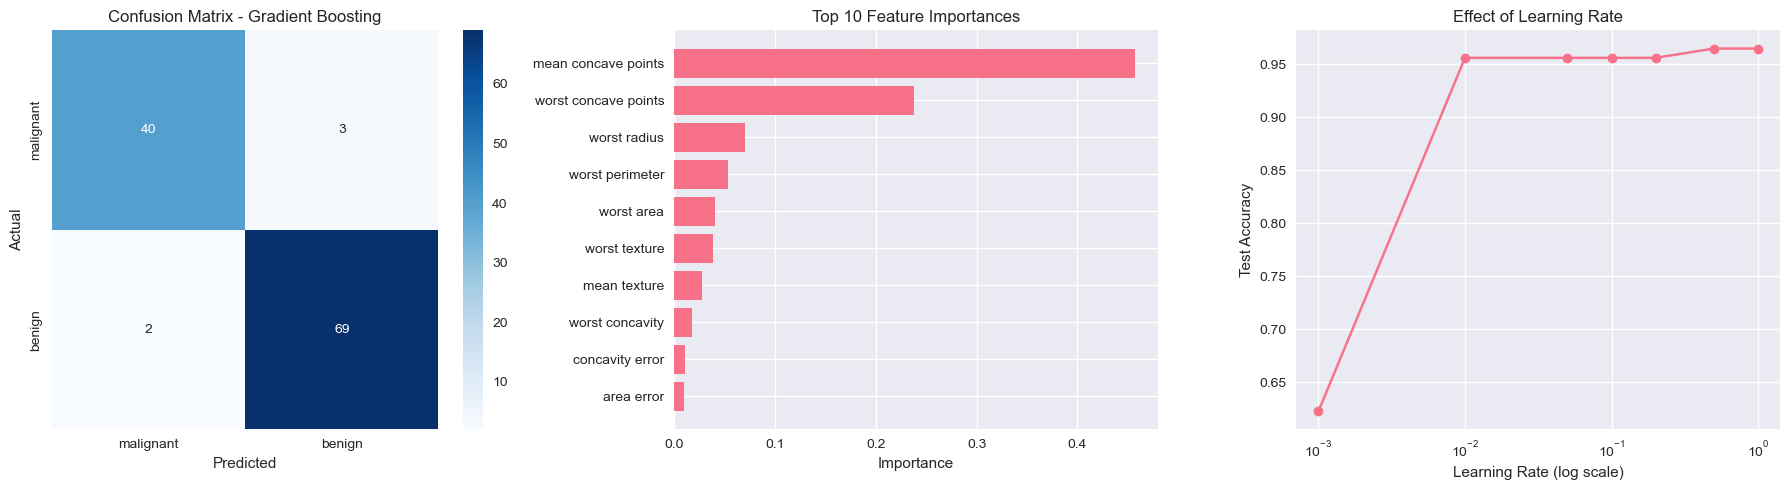


Key Insights:
- Smaller learning rate → more trees needed, but often better generalization.
- Gradient Boosting is often the best out-of-the-box model for tabular data.
- For production use, consider XGBoost or LightGBM (faster implementations).


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names,
            yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix - Gradient Boosting')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. Feature Importances
importances = gb.feature_importances_
top_indices = np.argsort(importances)[-10:]
axes[1].barh(range(10), importances[top_indices])
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([feature_names[i] for i in top_indices])
axes[1].set_title('Top 10 Feature Importances')
axes[1].set_xlabel('Importance')

# 3. Learning Rate Effect
lr_values = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
lr_test_accs = []
for lr in lr_values:
    gb_lr = GradientBoostingClassifier(n_estimators=100, learning_rate=lr, max_depth=3, random_state=42)
    gb_lr.fit(X_train, y_train)
    lr_test_accs.append(accuracy_score(y_test, gb_lr.predict(X_test)))

axes[2].semilogx(lr_values, lr_test_accs, marker='o')
axes[2].set_xlabel('Learning Rate (log scale)')
axes[2].set_ylabel('Test Accuracy')
axes[2].set_title('Effect of Learning Rate')
axes[2].grid(True)

plt.tight_layout()
plt.show()

print('\nKey Insights:')
print('- Smaller learning rate → more trees needed, but often better generalization.')
print('- Gradient Boosting is often the best out-of-the-box model for tabular data.')
print('- For production use, consider XGBoost or LightGBM (faster implementations).')

# Conclusions and Key Takeaways
Gradient Boosting is a powerful ensemble technique that builds models sequentially, with each new model attempting to correct the errors (residuals) made by the previous ones.
- **High Performance**: Frequently the algorithm of choice for tabular data, outperforming Deep Learning in many structured datasets.
- **Boosting**: Combines many weak learners (typically shallow decision trees) into a single strong learner.
- Uses gradient descent in function space to minimize the loss function.

# Pros and Cons
**Pros:**
- Often provides the highest predictive accuracy among traditional ML algorithms.
- Extremely flexible due to the ability to optimize various differentiable loss functions.
- Naturally handles complex non-linear relationships and interactions between features.

**Cons:**
- Prone to overfitting if not carefully tuned (especially regarding the number of estimators).
- Slower to train sequentially compared to bagging methods (like Random Forest) which can be parallelized natively.
- Less interpretable than single trees.

# 15 Interview Questions and Answers

1. **What is the core intuition behind Gradient Boosting?**
   *Answer*: It's an additive model where weak learners (usually decision trees) are trained sequentially. Each subsequent tree is trained on the negative gradient (often equivalent to the residual errors) of the combined model up to that point.

2. **How is Gradient Boosting different from Random Forest?**
   *Answer*: Random Forest builds fully grown trees independently and in parallel (Bagging), prioritizing variance reduction. Gradient Boosting builds shallow trees sequentially (Boosting), prioritizing bias reduction.

3. **What role does Gradient Descent play in Gradient Boosting?**
   *Answer*: The algorithm uses gradient descent optimization to find the parameters of the newly added tree that minimize the loss function of the entire model.

4. **What is the learning rate (shrinkage) in Gradient Boosting?**
   *Answer*: It is a multiplier (between 0 and 1) applied to the predictions of each individual tree before adding it to the ensemble. It slows down the learning process, which prevents the model from quickly memorizing the training data.

5. **How do learning rate and the number of estimators (trees) interact?**
   *Answer*: They trade off against each other. A lower learning rate requires a higher number of trees to reach the same level of complexity. Lowering the learning rate usually improves generalization but drastically increases training time.

6. **What is XGBoost?**
   *Answer*: Extreme Gradient Boosting. It's a highly optimized and scalable implementation of gradient boosting that includes hardware optimization, built-in L1/L2 regularization, and intelligent handling of missing values.

7. **What is LightGBM?**
   *Answer*: A Microsoft framework for gradient boosting that uses leaf-wise tree growth instead of level-wise, and histogram-based binning for continuous features, making it incredibly fast and memory-efficient for very large datasets.

8. **What is CatBoost?**
   *Answer*: A Yandex implementation of gradient boosting that handles categorical variables exceptionally well without requiring manual preprocessing (like one-hot encoding) and uses symmetric trees to reduce prediction time.

9. **Can Gradient Boosting overfit?**
    *Answer*: Yes. Unlike Random Forest, where adding more trees eventually plateaus in performance, adding too many trees in Gradient Boosting will almost certainly lead to overfitting because it continues to aggressively pursue zero training error.

10. **How do you prevent overfitting in Gradient Boosting?**
    *Answer*: Decrease the learning rate (while increasing trees), implement early stopping based on a validation set, use subsampling (Stochastic Gradient Boosting), add regularization (L1/L2), or restrict tree depth.

11. **Why do we use shallow trees (weak learners) in Gradient Boosting?**
    *Answer*: Shallow trees focus on specific patterns. Because trees are built consecutively, using weak learners ensures the model learns slowly and incrementally, which is the key to generalizing well rather than memorizing noise.

12. **What are the typical loss functions used in GBM?**
    *Answer*: Mean Squared Error (MSE), Mean Absolute Error (MAE), or Huber loss for regression; Log Loss (Binary Cross-Entropy) for classification.

13. **Is scaling necessary for Gradient Boosting Trees?**
    *Answer*: No, because the underlying base learners are decision trees, which are invariant to monotonic transformations and thus do not require scaling of features.

14. **How does Stochastic Gradient Boosting work?**
    *Answer*: Inspired by Bagging, it entails training each sequential tree on a random subsample of the training data (and sometimes a random subset of features) rather than the full dataset to increase variance among trees and prevent overfitting.

15. **What is Early Stopping in the context of GBM?**
    *Answer*: Validating the model's loss on a hold-out dataset at each boosting iteration. If the validation loss stops improving (or gets worse) for a specified number of consecutive iterations, training is halted early to prevent overfitting.
